# Image Classification - EMNIST Letters
Midterm Project | Josan Mauritz Sharon Nunuhitu | 4222301060


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import time, os, warnings
warnings.filterwarnings('ignore')


## 1. Load Dataset

In [2]:
TRAIN_PATH = "emnist-letters-train.csv"
TEST_PATH  = "emnist-letters-test.csv"

N_CLASSES        = 26
SAMPLES_PER_CLASS = 100
IMG_SIZE         = 28
SEED             = 42

if os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH):
    df_train = pd.read_csv(TRAIN_PATH, header=None)
    df_test  = pd.read_csv(TEST_PATH,  header=None)
    df_all   = pd.concat([df_train, df_test], ignore_index=True).dropna()
    y_raw = df_all.iloc[:, 0].values.astype(int) - 1  # jadi 0-25
    X_raw = df_all.iloc[:, 1:].values.astype(np.float32)
    print(f"dataset loaded: {X_raw.shape[0]} rows, {N_CLASSES} kelas")
else:
    print("CSV tidak ditemukan, pakai data simulasi")
    rng = np.random.RandomState(SEED)
    X_list, y_list = [], []
    for cls in range(N_CLASSES):
        mean = rng.uniform(50, 200, IMG_SIZE*IMG_SIZE)
        s = np.clip(rng.normal(mean, 30, (200, IMG_SIZE*IMG_SIZE)), 0, 255).astype(np.float32)
        X_list.append(s); y_list.append(np.full(200, cls))
    X_raw = np.vstack(X_list)
    y_raw = np.concatenate(y_list).astype(int)
    print(f"simulasi: {X_raw.shape[0]} rows")


dataset loaded: 103600 rows, 26 kelas


## 2. Balanced Sampling & Shuffle

In [3]:
np.random.seed(SEED)

X_bal, y_bal = [], []
for cls in range(N_CLASSES):
    idx = np.where(y_raw == cls)[0]
    chosen = np.random.choice(idx, SAMPLES_PER_CLASS, replace=False)
    X_bal.append(X_raw[chosen])
    y_bal.append(y_raw[chosen])

X_bal = np.vstack(X_bal)
y_bal = np.concatenate(y_bal)

# shuffle
perm = np.random.permutation(len(y_bal))
X_bal = X_bal[perm]
y_bal = y_bal[perm]

label_names = [chr(65+i) for i in range(26)]
print(f"total: {X_bal.shape[0]} samples, {N_CLASSES} kelas")
print({label_names[k]: v for k, v in zip(*np.unique(y_bal, return_counts=True))})


total: 2600 samples, 26 kelas
{'A': np.int64(100), 'B': np.int64(100), 'C': np.int64(100), 'D': np.int64(100), 'E': np.int64(100), 'F': np.int64(100), 'G': np.int64(100), 'H': np.int64(100), 'I': np.int64(100), 'J': np.int64(100), 'K': np.int64(100), 'L': np.int64(100), 'M': np.int64(100), 'N': np.int64(100), 'O': np.int64(100), 'P': np.int64(100), 'Q': np.int64(100), 'R': np.int64(100), 'S': np.int64(100), 'T': np.int64(100), 'U': np.int64(100), 'V': np.int64(100), 'W': np.int64(100), 'X': np.int64(100), 'Y': np.int64(100), 'Z': np.int64(100)}


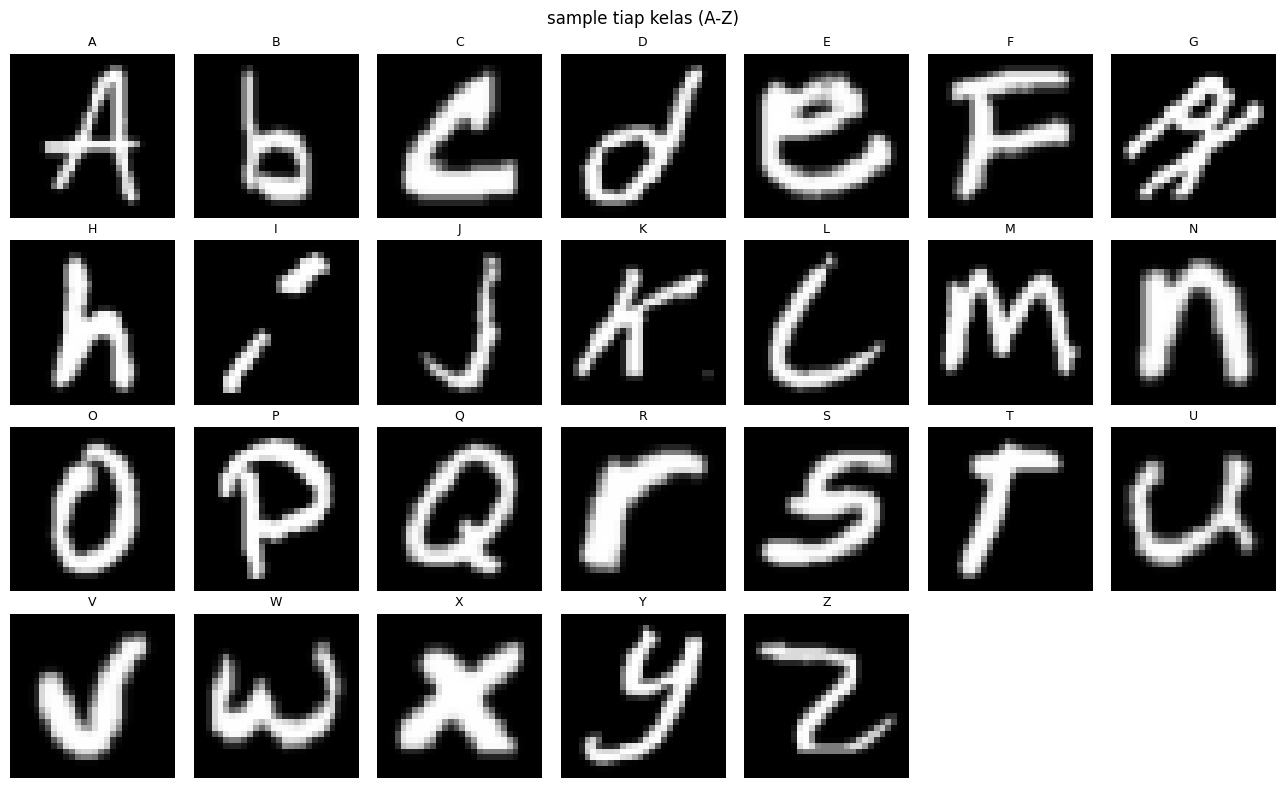

In [4]:
fig, axes = plt.subplots(4, 7, figsize=(13, 8))

for idx in range(26):
    r, c = divmod(idx, 7)
    i = np.where(y_bal == idx)[0][0]
    img = np.fliplr(np.rot90(X_bal[i].reshape(28,28), k=3))
    axes[r][c].imshow(img, cmap='gray')
    axes[r][c].set_title(label_names[idx], fontsize=9)
    axes[r][c].axis('off')

for idx in range(26, 28):
    r, c = divmod(idx, 7)
    axes[r][c].axis('off')

plt.suptitle("sample tiap kelas (A-Z)", fontsize=12)
plt.tight_layout()
plt.savefig("01_sample_images.png", dpi=120, bbox_inches='tight')
plt.show()


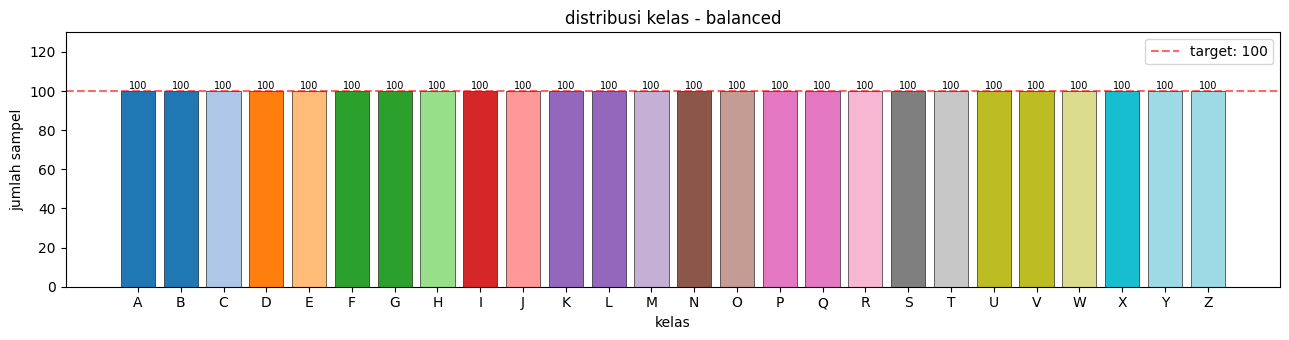

In [5]:
fig, ax = plt.subplots(figsize=(13, 3.5))
unique_c, counts = np.unique(y_bal, return_counts=True)
colors = plt.cm.tab20(np.linspace(0, 1, 26))
bars = ax.bar([label_names[c] for c in unique_c], counts, color=colors, edgecolor='black', lw=0.4)
ax.axhline(100, color='red', ls='--', alpha=0.6, label='target: 100')
ax.set_ylim(0, 130)
ax.set_xlabel('kelas'); ax.set_ylabel('jumlah sampel')
ax.set_title('distribusi kelas - balanced')
ax.legend()
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(cnt), ha='center', fontsize=7)
plt.tight_layout()
plt.savefig("02_class_distribution.png", dpi=120, bbox_inches='tight')
plt.show()


## 3. Train-Test Split (80/20)

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=SEED, stratify=y_bal
)
print(f"train : {len(X_train_raw)}")
print(f"test  : {len(X_test_raw)}")


train : 2080
test  : 520


## 4. HOG Feature Extraction

Parameter (beda dari default):
- `orientations=9` — cukup untuk tangkap bentuk huruf
- `pixels_per_cell=(4,4)` — resolusi lebih halus dari default (8,8)
- `cells_per_block=(2,2)`
- `transform_sqrt=True` — bantu normalisasi iluminasi


In [7]:
HOG_PARAMS = dict(
    orientations    = 9,
    pixels_per_cell = (4, 4),
    cells_per_block = (2, 2),
    block_norm      = 'L2-Hys',
    transform_sqrt  = True,
    visualize       = False
)

def extract_hog(X):
    feats = []
    for px in X:
        img = np.fliplr(np.rot90(px.reshape(28,28), k=3)) / 255.0
        feats.append(hog(img, **HOG_PARAMS))
    return np.nan_to_num(np.array(feats))

t0 = time.time()
X_train_hog = extract_hog(X_train_raw)
X_test_hog  = extract_hog(X_test_raw)
print(f"HOG selesai dalam {time.time()-t0:.1f}s")
print(f"feature length per gambar: {X_train_hog.shape[1]}")


HOG selesai dalam 2.7s
feature length per gambar: 1296


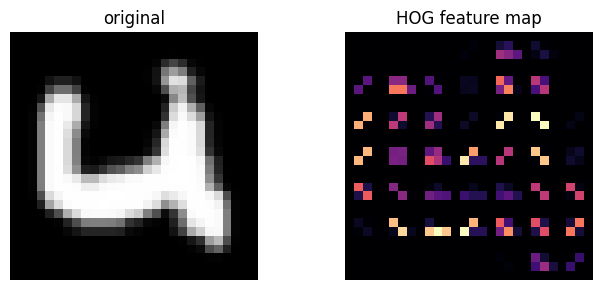

In [8]:
sample = np.fliplr(np.rot90(X_train_raw[0].reshape(28,28), k=3)) / 255.0
_, hog_img = hog(sample, **{**HOG_PARAMS, 'visualize': True})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))
ax1.imshow(sample, cmap='gray'); ax1.set_title('original'); ax1.axis('off')
ax2.imshow(exposure.rescale_intensity(hog_img, in_range=(0,10)), cmap='magma')
ax2.set_title('HOG feature map'); ax2.axis('off')
plt.tight_layout()
plt.savefig("03_hog_viz.png", dpi=120, bbox_inches='tight')
plt.show()


### Normalisasi Fitur (StandardScaler)

In [9]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_hog)
X_test_sc  = scaler.transform(X_test_hog)
print(f"train - mean: {X_train_sc.mean():.4f}, std: {X_train_sc.std():.4f}")
print(f"test  - mean: {X_test_sc.mean():.4f}, std: {X_test_sc.std():.4f}")


train - mean: 0.0000, std: 1.0000
test  - mean: -0.0028, std: 1.0142


## 5. SVM + Grid Search

In [10]:
param_grid = [
    {'kernel': ['rbf'],    'C': [1, 10, 50], 'gamma': ['scale', 0.01]},
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
]

gs = GridSearchCV(
    SVC(random_state=SEED),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
gs.fit(X_train_sc, y_train)
print(f"\nselesai dalam {time.time()-t0:.1f}s")
print(f"best params : {gs.best_params_}")
print(f"best CV acc : {gs.best_score_:.4f}")


Fitting 5 folds for each of 9 candidates, totalling 45 fits

selesai dalam 150.5s
best params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
best CV acc : 0.8163


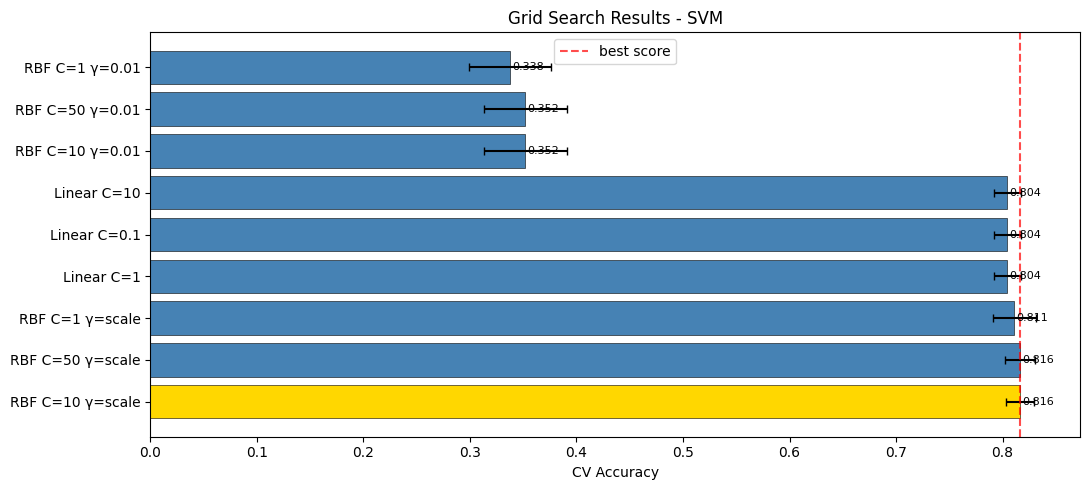

In [11]:
results = pd.DataFrame(gs.cv_results_).sort_values('mean_test_score', ascending=False)

def make_label(row):
    p = row['params']
    if p['kernel'] == 'rbf':
        return f"RBF C={p['C']} γ={p.get('gamma','')}"
    return f"Linear C={p['C']}"

results['label'] = results.apply(make_label, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
colors_bar = ['gold' if i == 0 else 'steelblue' for i in range(len(results))]
ax.barh(results['label'], results['mean_test_score'],
        xerr=results['std_test_score'], color=colors_bar,
        edgecolor='black', lw=0.4, capsize=3)
ax.axvline(gs.best_score_, color='red', ls='--', alpha=0.7, label='best score')
ax.set_xlabel('CV Accuracy')
ax.set_title('Grid Search Results - SVM')
ax.legend()
for _, row in results.iterrows():
    ax.text(row['mean_test_score']+0.002, results.index.get_loc(row.name),
            f"{row['mean_test_score']:.3f}", va='center', fontsize=8)
plt.tight_layout()
plt.savefig("04_gridsearch.png", dpi=120, bbox_inches='tight')
plt.show()


## 6. Evaluasi

In [12]:
best_model = gs.best_estimator_

y_train_pred = best_model.predict(X_train_sc)
y_test_pred  = best_model.predict(X_test_sc)

def get_metrics(y_true, y_pred):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

train_m = get_metrics(y_train, y_train_pred)
test_m  = get_metrics(y_test,  y_test_pred)

print("--- Training Set ---")
for k, v in train_m.items(): print(f"  {k:<10}: {v:.4f}")
print("\n--- Test Set ---")
for k, v in test_m.items():  print(f"  {k:<10}: {v:.4f}")


--- Training Set ---
  accuracy  : 1.0000
  precision : 1.0000
  recall    : 1.0000
  f1        : 1.0000

--- Test Set ---
  accuracy  : 0.8154
  precision : 0.8240
  recall    : 0.8154
  f1        : 0.8156


In [13]:
print(classification_report(y_test, y_test_pred, target_names=label_names))


              precision    recall  f1-score   support

           A       0.85      0.85      0.85        20
           B       1.00      0.85      0.92        20
           C       0.79      0.95      0.86        20
           D       0.86      0.90      0.88        20
           E       0.94      0.75      0.83        20
           F       0.81      0.85      0.83        20
           G       0.68      0.65      0.67        20
           H       0.82      0.90      0.86        20
           I       0.53      0.45      0.49        20
           J       0.84      0.80      0.82        20
           K       0.90      0.90      0.90        20
           L       0.52      0.60      0.56        20
           M       0.94      0.85      0.89        20
           N       0.85      0.85      0.85        20
           O       1.00      0.95      0.97        20
           P       0.94      0.85      0.89        20
           Q       0.71      0.75      0.73        20
           R       0.69    

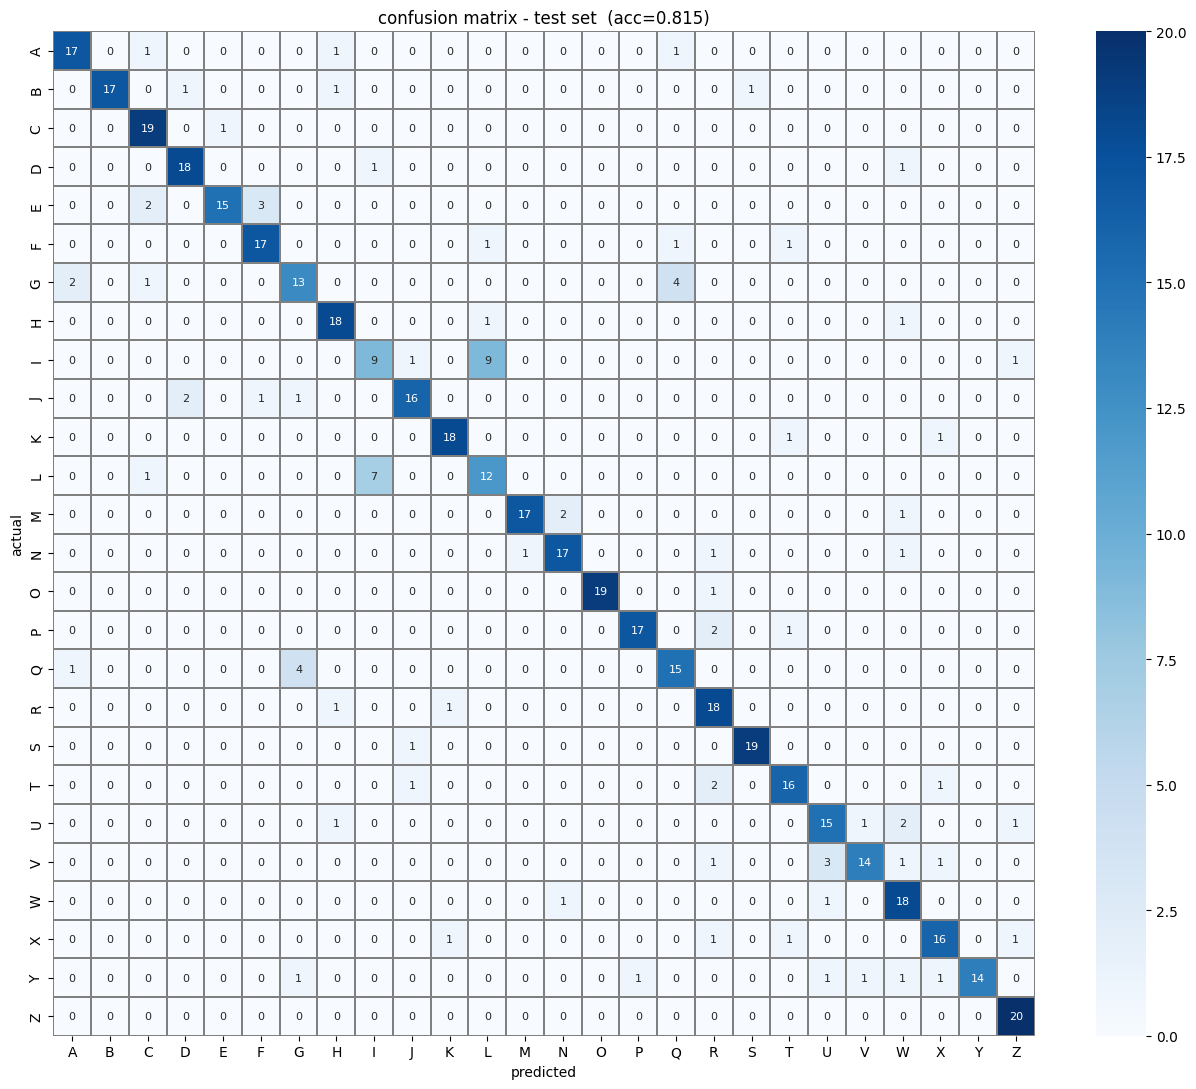

In [14]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.3, linecolor='gray',
            annot_kws={'size': 8}, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title(f'confusion matrix - test set  (acc={test_m["accuracy"]:.3f})')
plt.tight_layout()
plt.savefig("05_confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()


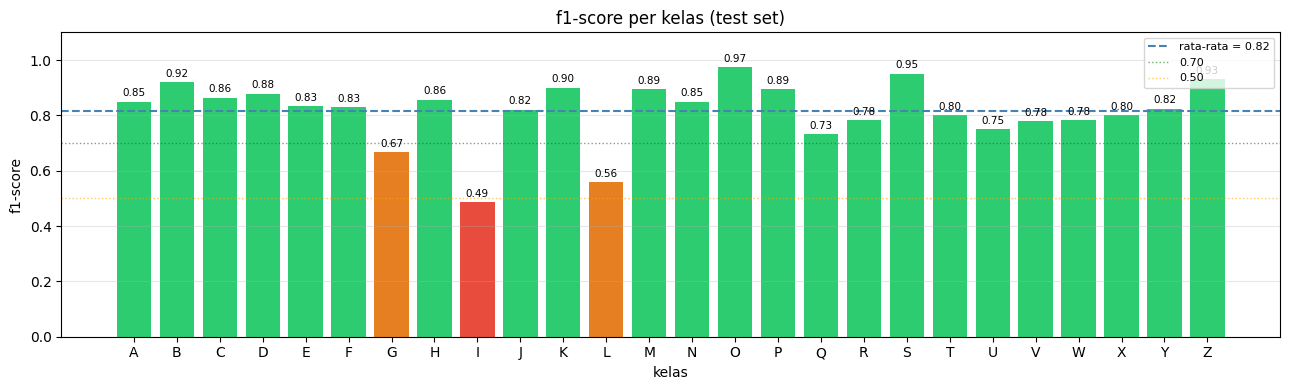

tertinggi: O (0.974)
terendah : I (0.486)


In [15]:
f1_cls = f1_score(y_test, y_test_pred, average=None, zero_division=0)
warna  = ['#2ecc71' if v>=0.7 else '#e67e22' if v>=0.5 else '#e74c3c' for v in f1_cls]

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(label_names, f1_cls, color=warna, edgecolor='none')
ax.axhline(np.mean(f1_cls), color='steelblue', ls='--', lw=1.5,
           label=f'rata-rata = {np.mean(f1_cls):.2f}')
ax.axhline(0.7, color='green',  ls=':', lw=1, alpha=0.6, label='0.70')
ax.axhline(0.5, color='orange', ls=':', lw=1, alpha=0.6, label='0.50')
ax.set_ylim(0, 1.1); ax.set_xlabel('kelas'); ax.set_ylabel('f1-score')
ax.set_title('f1-score per kelas (test set)'); ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_cls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.2f}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.savefig("06_f1_per_class.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"tertinggi: {label_names[np.argmax(f1_cls)]} ({f1_cls.max():.3f})")
print(f"terendah : {label_names[np.argmin(f1_cls)]} ({f1_cls.min():.3f})")


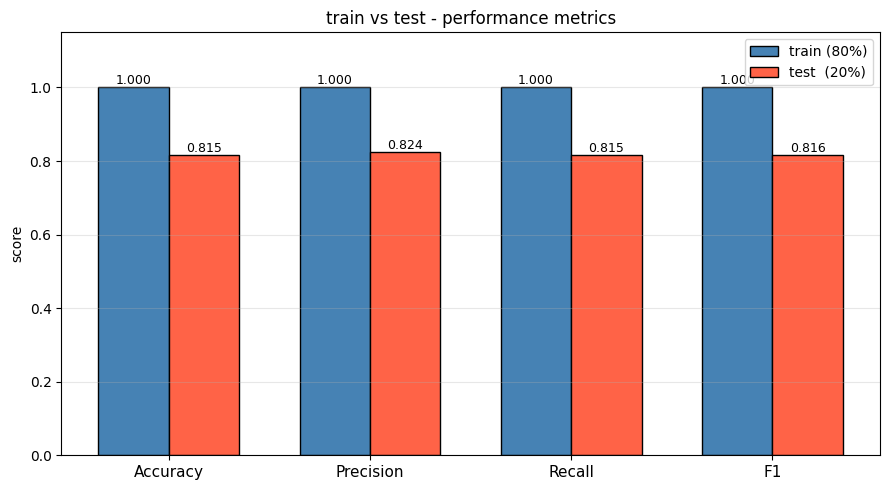

In [16]:
metrics_keys = ['accuracy', 'precision', 'recall', 'f1']
train_vals = [train_m[k] for k in metrics_keys]
test_vals  = [test_m[k]  for k in metrics_keys]
x = np.arange(4); w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, train_vals, w, label='train (80%)', color='steelblue', edgecolor='black')
b2 = ax.bar(x+w/2, test_vals,  w, label='test  (20%)', color='tomato',    edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(['Accuracy','Precision','Recall','F1'], fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('score')
ax.set_title('train vs test - performance metrics')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{b.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("07_train_vs_test.png", dpi=120, bbox_inches='tight')
plt.show()


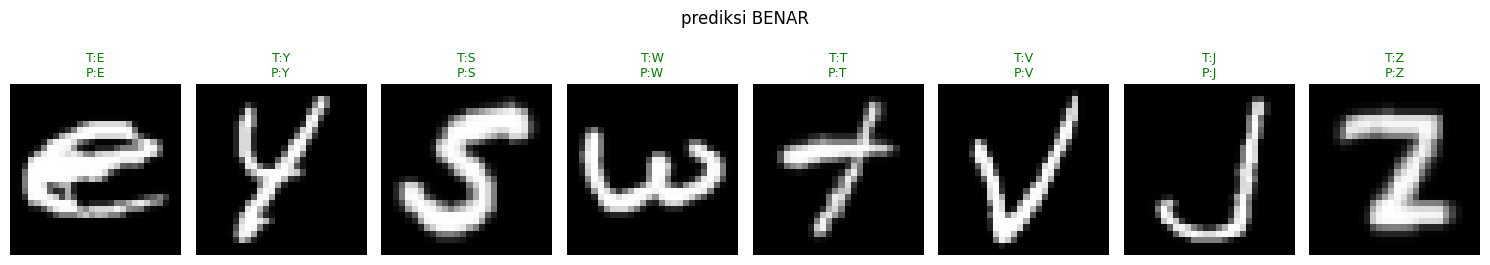

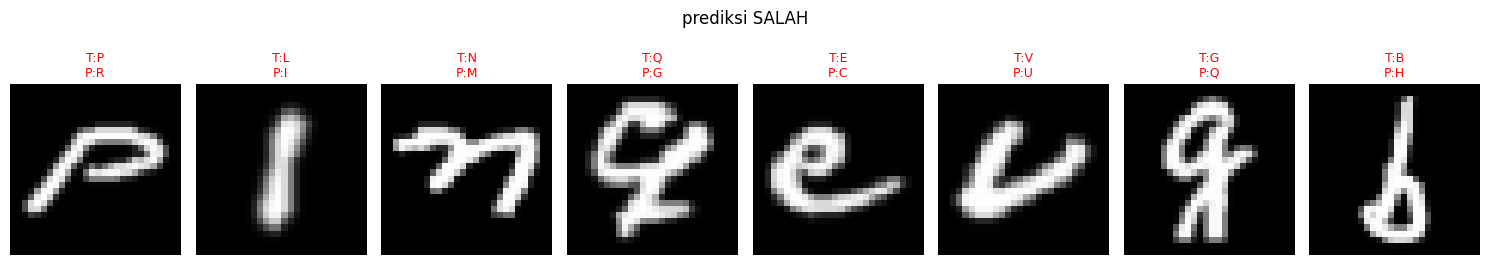

In [17]:
correct_idx   = np.where(y_test_pred == y_test)[0]
incorrect_idx = np.where(y_test_pred != y_test)[0]

def show_preds(indices, title, color, filename):
    n = min(8, len(indices))
    if n == 0: return
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=12)
    for i in range(n):
        ci = indices[i]
        img = np.fliplr(np.rot90(X_test_raw[ci].reshape(28,28), k=3))
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"T:{label_names[y_test[ci]]}\nP:{label_names[y_test_pred[ci]]}",
                          color=color, fontsize=9)
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()

show_preds(correct_idx,   "prediksi BENAR", "green", "08a_correct.png")
show_preds(incorrect_idx, "prediksi SALAH", "red",   "08b_wrong.png")


In [18]:
print("=" * 55)
print("         RINGKASAN HASIL")
print("=" * 55)
print(f"  dataset        : EMNIST Letters")
print(f"  total samples  : 2600 (26 kelas x 100)")
print(f"  train/test     : {len(X_train_raw)} / {len(X_test_raw)}")
print(f"  HOG features   : {X_train_hog.shape[1]} per gambar")
print(f"    orientations    = 9")
print(f"    pixels_per_cell = (4,4)")
print(f"    cells_per_block = (2,2)")
print(f"    transform_sqrt  = True")
print(f"  best SVM params: {gs.best_params_}")
print()
print(f"  {'metric':<12} {'train':>10} {'test':>10}")
print(f"  {'-'*32}")
for k in ['accuracy','precision','recall','f1']:
    print(f"  {k:<12} {train_m[k]:>10.4f} {test_m[k]:>10.4f}")
print("=" * 55)


         RINGKASAN HASIL
  dataset        : EMNIST Letters
  total samples  : 2600 (26 kelas x 100)
  train/test     : 2080 / 520
  HOG features   : 1296 per gambar
    orientations    = 9
    pixels_per_cell = (4,4)
    cells_per_block = (2,2)
    transform_sqrt  = True
  best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

  metric            train       test
  --------------------------------
  accuracy         1.0000     0.8154
  precision        1.0000     0.8240
  recall           1.0000     0.8154
  f1               1.0000     0.8156
